In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import platform
import os
import glob

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

mpl.rcParams['axes.unicode_minus'] = False

file_path = "data/2024.csv" ## 자기 경로로 바꾸기
whole_df = pd.read_csv(file_path,encoding='cp949', parse_dates=["계약일","취소일"])

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_10089/1557329566.py:26: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  whole_df = pd.read_csv(file_path,encoding='cp949', parse_dates=["계약일","취소일"])


In [59]:
from sklearn.preprocessing import StandardScaler

## 중심극한정리

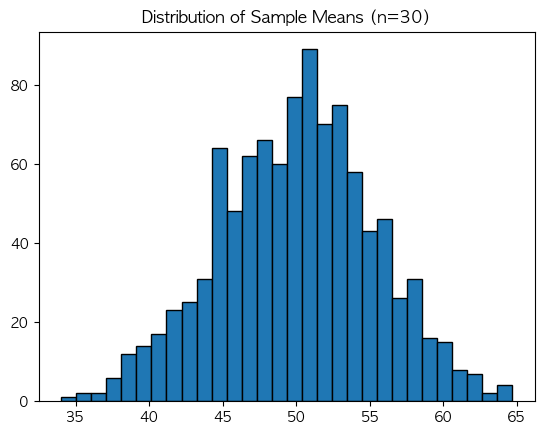

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 모집단: 0~100 사이의 균등분포 (전혀 정규분포가 아님)
population = np.random.uniform(0, 100, 10000)

sample_means = []
n = 30  # 표본의 크기
iterations = 1000 # 표본 추출 반복 횟수

for _ in range(iterations):
    sample = np.random.choice(population, size=n)
    sample_means.append(np.mean(sample))

# 2. 표본평균들의 분포 시각화
plt.hist(sample_means, bins=30, edgecolor='black')
plt.title(f"Distribution of Sample Means (n={n})")
plt.show()

## 표본 개수에 따른 표준오차 확인

In [61]:
# 표본 개수에 따른 표준오차 확인

import numpy as np

# 모집단 설정 (평균 50, 표준편차 15)
pop_std = 15

# 표본 크기 시나리오
n_small = 5
n_large = 100

# 표준오차(Standard Error) 계산
se_small = pop_std / np.sqrt(n_small)
se_large = pop_std / np.sqrt(n_large)

print(f"n=5 일 때의 표준오차: {se_small:.2f}")
print(f"n=100 일 때의 표준오차: {se_large:.2f}")

# 결과 해석: n이 20배 커지면, 오차의 범위는 약 1/4.5 수준으로 감소함

n=5 일 때의 표준오차: 6.71
n=100 일 때의 표준오차: 1.50


## 확률 분포 그려보기

In [62]:
df = whole_df[['건물명','자치구코드', '자치구명', '법정동코드', '법정동명','층','건물용도','물건금액(만원)', '건물면적(㎡)', '토지면적(㎡)','계약일']]
df.columns = ['건물명','자치구코드', '자치구명', '법정동코드', '법정동명','층','건물용도','물건금액', '건물면적', '토지면적','계약일']

In [63]:
df.dropna(inplace=True)

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_10089/1379821321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [64]:
df.describe()

,자치구코드,법정동코드,층,물건금액,건물면적,토지면적,계약일
count,69886.00,69886.00,69886.00,69886.00,69886.00,69886.00,69886
mean,11458.72,10928.45,7.75,84213.44,62.23,14.01,2024-05-30 05:08:49.651146240
min,11110.00,10100.00,-2.00,2600.00,8.48,0.00,2022-07-08 00:00:00
25%,11305.00,10200.00,3.00,30000.00,40.20,0.00,2024-03-31 00:00:00
50%,11470.00,10600.00,6.00,62000.00,59.85,0.00,2024-06-13 00:00:00
75%,11620.00,11000.00,11.00,110000.00,84.77,25.40,2024-07-27 00:00:00
max,11740.00,18700.00,68.00,2200000.00,288.40,30822.00,2024-10-14 00:00:00
std,177.45,1199.78,6.30,80280.77,29.74,118.68,NaN


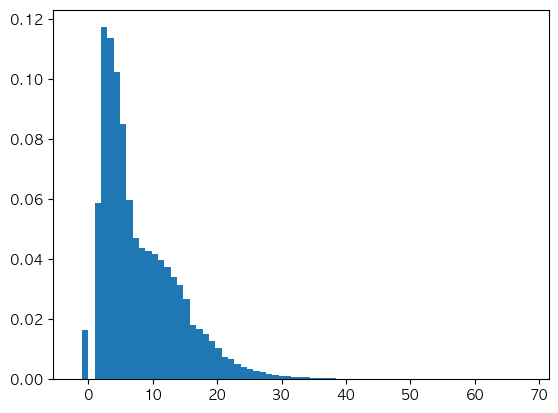

In [65]:
plt.hist(df['층'],bins=71,density=True)
plt.show()

In [66]:
df['층'].value_counts(normalize=True)

층
2.00    0.12
3.00    0.11
4.00    0.10
5.00    0.08
6.00    0.06
        ... 
60.00   0.00
52.00   0.00
67.00   0.00
63.00   0.00
64.00   0.00
Name: proportion, Length: 61, dtype: float64

2024년 거래된 매물 중에서 2층이 차지하는 비율은 약 12%에 달한다

2024년에 거래된 매물 중에서 아무거나 1개를 선택했을 때, 2층일 확률이 12%이다. 

## 표준화

In [67]:
multiplex_house_df = df.loc[df['건물용도']=='연립다세대']

In [68]:
multiplex_house_df.describe()

,자치구코드,법정동코드,층,물건금액,건물면적,토지면적,계약일
count,21183.00,21183.00,21183.00,21183.00,21183.00,21183.00,21183
mean,11443.34,10850.47,3.03,35977.08,45.19,29.49,2024-05-18 17:43:36.003398912
min,11110.00,10100.00,-2.00,2600.00,8.48,3.00,2022-07-08 00:00:00
25%,11305.00,10200.00,2.00,22300.00,29.93,19.00,2024-03-15 00:00:00
50%,11440.00,10500.00,3.00,30000.00,43.02,25.00,2024-05-23 00:00:00
75%,11590.00,10900.00,4.00,40500.00,55.43,32.00,2024-07-26 00:00:00
max,11740.00,18700.00,18.00,1085000.00,288.40,30822.00,2024-10-14 00:00:00
std,168.33,1156.70,1.88,32384.91,19.72,212.72,NaN


In [69]:
# IQR 방식의 이상치 제거
area_data = multiplex_house_df['토지면적'].values
q_1 = np.percentile(area_data, q=25)
q_3 = np.percentile(area_data, q=75)
iqr = q_3 - q_1

In [70]:
lower_whisker = q_1 - 1.5 * iqr 
upper_whisker = q_3 + 1.5 * iqr

In [71]:
# 이상치 제거한 데이터 나오게끔 해보기! 
# multiplex_house_df_cleaned = multiplex_house_df.loc[(multiplex_house_df['토지면적']<=upper_whisker) & (multiplex_house_df['토지면적']>=lower_whisker)]
multiplex_house_df_cleaned = multiplex_house_df.loc[multiplex_house_df['토지면적'].between(lower_whisker,upper_whisker)]
# multiplex_house_df_cleaned = multiplex_house_df.loc[(multiplex_house_df['토지면적']>=lower_whisker)&(multiplex_house_df['토지면적']<=upper_whisker)]

In [72]:
multiplex_house_df_cleaned

,건물명,자치구코드,자치구명,법정동코드,법정동명,층,건물용도,물건금액,건물면적,토지면적,계약일
0,성원빌라(86-125),11380,은평구,10200,녹번동,4.00,연립다세대,16400,53.07,25.00,2024-10-14
1,팔팔빌라,11500,강서구,10300,화곡동,2.00,연립다세대,35000,39.24,27.00,2024-10-14
2,다솔시티하임,11560,영등포구,11100,당산동1가,5.00,연립다세대,30000,29.54,14.00,2024-10-14
9,진광,11500,강서구,10600,내발산동,1.00,연립다세대,15900,37.98,20.00,2024-10-14
11,오복홈타운,11590,동작구,10200,상도동,2.00,연립다세대,30000,62.30,43.00,2024-10-14
...,...,...,...,...,...,...,...,...,...,...,...
77505,그레이스빌2차A,11440,마포구,12200,합정동,5.00,연립다세대,26300,22.44,12.65,2023-11-13
77509,(243-9),11170,용산구,13000,이태원동,1.00,연립다세대,39100,40.48,36.00,2023-08-30
77512,가온리치빌(씨동),11305,강북구,10300,수유동,2.00,연립다세대,23000,29.64,21.54,2023-04-07
77513,(410-23),11440,마포구,12300,망원동,2.00,연립다세대,20000,23.82,16.00,2023-03-13


In [73]:
# 오복홈타운의 데이터 확인하기 
obok = multiplex_house_df_cleaned.loc[multiplex_house_df_cleaned['건물명']=='오복홈타운']

In [74]:
obok.isna().sum()

건물명      0
자치구코드    0
자치구명     0
법정동코드    0
법정동명     0
층        0
건물용도     0
물건금액     0
건물면적     0
토지면적     0
계약일      0
dtype: int64

In [75]:
obok['건물면적'].describe()

count    1.00
mean    62.30
std       NaN
min     62.30
25%     62.30
50%     62.30
75%     62.30
max     62.30
Name: 건물면적, dtype: float64

In [76]:
multiplex_house_df_cleaned['건물면적'].describe()

count   20261.00
mean       43.26
std        15.48
min         8.48
25%        29.89
50%        41.96
75%        54.02
max       153.88
Name: 건물면적, dtype: float64

In [77]:
building_z = (obok['건물면적'] - multiplex_house_df_cleaned['건물면적'].mean()) / multiplex_house_df_cleaned['건물면적'].std()
print(building_z) # 1.73

11   1.23
Name: 건물면적, dtype: float64


In [78]:
multiplex_house_df_cleaned['토지면적'].describe()

count   20261.00
mean       25.15
std         8.70
min         3.00
25%        18.80
50%        25.00
75%        31.00
max        51.00
Name: 토지면적, dtype: float64

In [79]:
land_z = (obok['토지면적'] - multiplex_house_df_cleaned['토지면적'].mean()) / multiplex_house_df_cleaned['토지면적'].std()
print(land_z)

11   2.05
Name: 토지면적, dtype: float64


- 연립다세대주택 중에서 오복홈타운의 건물 면적과 토지면적은 높은 편일까? 
  => 평균보다 높은가? 
- 만약 둘 다 평균보다 높다고 나온다면, 오복홈타운의 건물면적과 토지면적 중 어떤 면적이 평균에서 더 멀리 떨어져있을까?

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

multiplex_house_df_cleaned['건물면적_표준화']=  scaler.fit_transform(multiplex_house_df_cleaned[['건물면적']])
multiplex_house_df_cleaned['토지면적_표준화']=  scaler.fit_transform(multiplex_house_df_cleaned[['토지면적']])

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_10089/15804999.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multiplex_house_df_cleaned['건물면적_표준화']=  scaler.fit_transform(multiplex_house_df_cleaned[['건물면적']])
/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_10089/15804999.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multiplex_house_df_cleaned['토지면적_표준화']=  scaler.fit_transform(multiplex_house_df_cleaned[['토지면적']])


In [81]:
multiplex_house_df_cleaned

,건물명,자치구코드,자치구명,법정동코드,법정동명,층,건물용도,물건금액,건물면적,토지면적,계약일,건물면적_표준화,토지면적_표준화
0,성원빌라(86-125),11380,은평구,10200,녹번동,4.00,연립다세대,16400,53.07,25.00,2024-10-14,0.63,-0.02
1,팔팔빌라,11500,강서구,10300,화곡동,2.00,연립다세대,35000,39.24,27.00,2024-10-14,-0.26,0.21
2,다솔시티하임,11560,영등포구,11100,당산동1가,5.00,연립다세대,30000,29.54,14.00,2024-10-14,-0.89,-1.28
9,진광,11500,강서구,10600,내발산동,1.00,연립다세대,15900,37.98,20.00,2024-10-14,-0.34,-0.59
11,오복홈타운,11590,동작구,10200,상도동,2.00,연립다세대,30000,62.30,43.00,2024-10-14,1.23,2.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
77505,그레이스빌2차A,11440,마포구,12200,합정동,5.00,연립다세대,26300,22.44,12.65,2023-11-13,-1.35,-1.44
77509,(243-9),11170,용산구,13000,이태원동,1.00,연립다세대,39100,40.48,36.00,2023-08-30,-0.18,1.25
77512,가온리치빌(씨동),11305,강북구,10300,수유동,2.00,연립다세대,23000,29.64,21.54,2023-04-07,-0.88,-0.41
77513,(410-23),11440,마포구,12300,망원동,2.00,연립다세대,20000,23.82,16.00,2023-03-13,-1.26,-1.05


In [82]:
target = multiplex_house_df_cleaned.loc[multiplex_house_df_cleaned['건물명']=='오복홈타운']
target

,건물명,자치구코드,자치구명,법정동코드,법정동명,층,건물용도,물건금액,건물면적,토지면적,계약일,건물면적_표준화,토지면적_표준화
11,오복홈타운,11590,동작구,10200,상도동,2.00,연립다세대,30000,62.30,43.00,2024-10-14,1.23,2.05


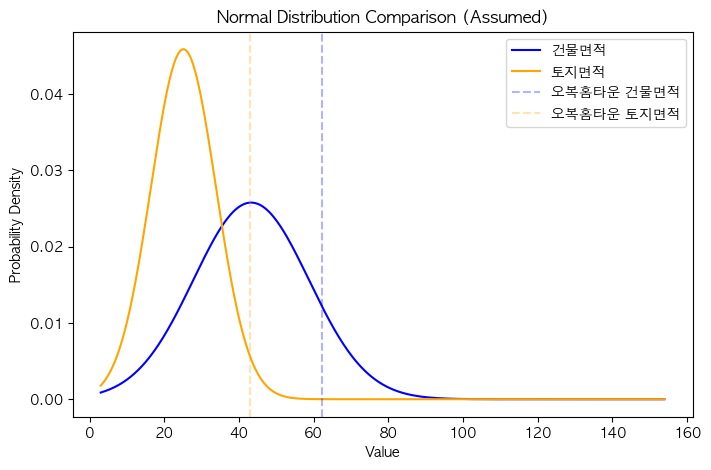

In [83]:
## 지금 이 코드는 이해하지 않아도 됩니다! 복붙해서 그림만 봐주세요

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

data_A = multiplex_house_df_cleaned['건물면적']
data_B = multiplex_house_df_cleaned['토지면적']


# 두 변수의 평균과 표준편차
mu_A, sigma_A = np.mean(data_A), np.std(data_A)
mu_B, sigma_B = np.mean(data_B), np.std(data_B)

# x 범위 (두 분포를 모두 포함하도록)
x = np.linspace(
    min(min(data_A),min(data_B)),
    max(max(data_A),max(data_B)),
    500
)

# PDF 계산
pdf_A = norm.pdf(x, mu_A, sigma_A)
pdf_B = norm.pdf(x, mu_B, sigma_B)

# 시각화
plt.figure(figsize=(8,5))
plt.plot(x, pdf_A, label="건물면적",color ='blue')
plt.plot(x, pdf_B, label="토지면적",color ='orange')

plt.axvline(x=target['건물면적'].values,linestyle = "--", alpha=0.3, label="오복홈타운 건물면적",color ='blue')
plt.axvline(x=target['토지면적'].values,linestyle = "--", alpha=0.3, label="오복홈타운 토지면적",color='orange')


plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.title("Normal Distribution Comparison (Assumed)")
plt.legend()
plt.show()

In [84]:
from scipy.stats import norm

# 건물면적의 평균 50, 표준편차 10 가정
mu, sigma = 50, 10

# 1. 확률밀도(높이): 50일 때의 밀도
density_50 = norm.pdf(50, mu, sigma) 
print(f"평균 지점의 밀도(높이): {density_50}") # 0.0398

# 2. 확률(면적): 면적이 40에서 60 사이일 확률
prob_40_60 = norm.cdf(60, mu, sigma) - norm.cdf(40, mu, sigma)
print(f"40~60 사이의 확률(면적): {prob_40_60:.4f}") # 약 0.6827

평균 지점의 밀도(높이): 0.03989422804014327
40~60 사이의 확률(면적): 0.6827


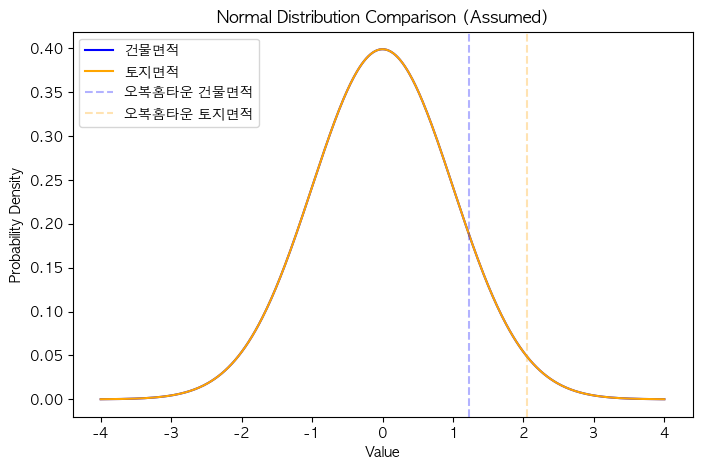

In [85]:
## 지금 이 코드는 이해하지 않아도 됩니다! 복붙해서 그림만 봐주세요

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

data_A = multiplex_house_df_cleaned['건물면적_표준화']
data_B = multiplex_house_df_cleaned['토지면적_표준화']
# 두 변수의 평균과 표준편차
mu_A, sigma_A = 0,1
mu_B, sigma_B = 0,1

# x 범위 (두 분포를 모두 포함하도록)
x = np.linspace(
    -4,4,500
)

# PDF 계산
pdf_A = norm.pdf(x, mu_A, sigma_A)
pdf_B = norm.pdf(x, mu_B, sigma_B)

# 시각화
plt.figure(figsize=(8,5))
plt.plot(x, pdf_A, label="건물면적",color ='blue')
plt.plot(x, pdf_B, label="토지면적",color ='orange')

plt.axvline(x=target['건물면적_표준화'].values,linestyle = "--", alpha=0.3, label="오복홈타운 건물면적",color ='blue')
plt.axvline(x=target['토지면적_표준화'].values,linestyle = "--", alpha=0.3, label="오복홈타운 토지면적",color='orange')


plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.title("Normal Distribution Comparison (Assumed)")
plt.legend()
plt.show()

- 연립다세대주택 중에서 오복홈타운의 건물 면적과 토지면적은 평균보다 높은가?  
  - 그렇다
- 만약 둘 다 평균보다 높다고 나온다면, 오복홈타운의 건물면적과 토지면적 중 어떤 면적이 평균에서 더 멀리 떨어져있을까?
  - 토지면적이 더 멀리 떨어졌다. 표준화 점수를 비교해보니 토지면적의 표준화점수가 건물면적의 표준화 점수보다 높게 나왔다. 토지면적이 토지면적의 평균에서 떨어진 정도가 건물면적이 건물면적의 평균에서 떨어진 정도보다 더 크다는 걸 의미한다. 

## 신뢰구간 구하기

In [86]:
multiplex_house_df

,건물명,자치구코드,자치구명,법정동코드,법정동명,층,건물용도,물건금액,건물면적,토지면적,계약일
0,성원빌라(86-125),11380,은평구,10200,녹번동,4.00,연립다세대,16400,53.07,25.00,2024-10-14
1,팔팔빌라,11500,강서구,10300,화곡동,2.00,연립다세대,35000,39.24,27.00,2024-10-14
2,다솔시티하임,11560,영등포구,11100,당산동1가,5.00,연립다세대,30000,29.54,14.00,2024-10-14
9,진광,11500,강서구,10600,내발산동,1.00,연립다세대,15900,37.98,20.00,2024-10-14
11,오복홈타운,11590,동작구,10200,상도동,2.00,연립다세대,30000,62.30,43.00,2024-10-14
...,...,...,...,...,...,...,...,...,...,...,...
77516,세종에버그린(101동),11215,광진구,10700,화양동,8.00,연립다세대,30000,27.55,9.88,2023-01-24
77517,금석연립(170-33),11530,구로구,10700,개봉동,2.00,연립다세대,9740,53.61,124.00,2022-07-08
77518,금석연립(170-33),11530,구로구,10700,개봉동,1.00,연립다세대,9190,53.61,124.00,2022-07-08
77519,금석연립(170-33),11530,구로구,10700,개봉동,1.00,연립다세대,9190,53.61,124.00,2022-07-08


지금 우리가 알고 싶은 건 서울에 있는 모든 연립 다세대 주택의 물건금액 평균을 알아내는 것이다. <br>
하지만 우리는 약 2만개의 데이터만 가지고 있다. <br>
이 데이터를 가지고, 연립 다세대 주택의 물건 금액 평균을 추정해보자. 

우선 건물명, 자치구, 법정동, 층이 일치하는 데이터는 계약일이 가장 최근인 데이터만 남긴다. 

In [87]:
# 같은 매물 데이터는 중복 제거
multiplex_house_only_df = multiplex_house_df.sort_values(['건물명','자치구코드','법정동코드','층','계약일'])\
                            .drop_duplicates(subset=['건물명','자치구코드','법정동코드','층'],keep='last')

In [88]:
multiplex_house_only_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17469 entries, 63288 to 28006
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   건물명     17469 non-null  object        
 1   자치구코드   17469 non-null  int64         
 2   자치구명    17469 non-null  object        
 3   법정동코드   17469 non-null  int64         
 4   법정동명    17469 non-null  object        
 5   층       17469 non-null  float64       
 6   건물용도    17469 non-null  object        
 7   물건금액    17469 non-null  int64         
 8   건물면적    17469 non-null  float64       
 9   토지면적    17469 non-null  float64       
 10  계약일     17469 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(3), object(4)
memory usage: 1.6+ MB


In [89]:
sample_data = multiplex_house_only_df['물건금액']

#표본 개수 
n = len(sample_data)

#표본의 평균
sample_mean = np.mean(sample_data)

#표본의 표준편차
s = np.std(sample_data,ddof=1)

#표준오차의 근사값
se = s/np.sqrt(n)

# 신뢰구간 구하기
stats.t.interval(confidence=0.95, df = n-1, loc = sample_mean , scale=se)

(np.float64(34671.77286052314), np.float64(35596.37837881512))

95% 신뢰수준에서 서울 연립 다세대 주택의 물건금액 평균은 34,671만원에서 35,596만원 사이에 있다. 